## KNN

**Speed note:** the full dataset has ~735,000 rows (590k train / 147k test after the
80/20 split). KNN's prediction cost scales with `train_size x test_size`, so running
every step on the full data would take hours. Every step below uses an appropriately
sized **stratified subsample** to keep total runtime under ~20 minutes, while still
producing valid, defensible results: the final tuned model's headline numbers come
from a 15,000-row stratified test subsample, which is large enough to be statistically
reliable (the original Safe/Unsafe ratio is preserved via `stratify=`).

### KNN 建模步骤：
1. 数据准备 — 分离特征（X）和目标变量（y）
2. 类别变量编码 — Color (ordinal), Source (one-hot)
3. 训练集与测试集划分
4. 特征筛选（相关性） — 降维以加速距离计算
5. 特征缩放 — StandardScaler
6. Baseline KNN（K=5）训练与评估（在子样本上）
7. 5-Fold CV（在子样本上）
8. Elbow Search（在子样本上）
9. 超参数搜索：tqdm + 手动网格搜索（在子样本上）
10. 用最优参数重新在全量训练集上训练最终模型
11. 最终模型评估（在统一的测试子样本上）
12. Confusion Matrix & ROC Curve

In [3]:
import pandas as pd
import numpy as np
import time
import itertools
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve
)

try:
    from tqdm import tqdm
except ImportError:
    !pip install tqdm --quiet
    from tqdm import tqdm

In [4]:
# Load cleaned data — adjust path if needed (Colab default working dir is /content/)
#df = pd.read_csv("/content/water_quality_cleaned.csv")
df = pd.read_csv("C:/Users/Fan_y/Desktop/water_quality_cleaned.csv")

print("Shape:", df.shape)
print("\nMissing values per column:")
print(df.isna().sum())
print("\nTarget dtype:", df['Target'].dtype, "| unique values:", df['Target'].unique())

Shape: (734756, 23)

Missing values per column:
pH                        0
Iron                      0
Nitrate                   0
Chloride                  0
Lead                      0
Zinc                      0
Color                     0
Turbidity                 0
Fluoride                  0
Copper                    0
Odor                      0
Sulfate                   0
Conductivity              0
Chlorine                  0
Manganese                 0
Total Dissolved Solids    0
Source                    0
Water Temperature         0
Air Temperature           0
Month                     0
Day                       0
Time of Day               0
Target                    0
dtype: int64

Target dtype: int64 | unique values: [0 1]


#### 1. Data Preparation

In [5]:
X_knn = df.drop(columns=['Target'])
y_knn = df['Target']

print("X_knn shape:", X_knn.shape)
print("y_knn shape:", y_knn.shape)

X_knn shape: (734756, 22)
y_knn shape: (734756,)


#### 2. Categorical Encoding
* Source: unordered categories -> one-hot encoding
* Color: ordered by contamination severity -> ordinal encoding

In [6]:
print("Color categories:", X_knn['Color'].unique())
print("Source categories:", X_knn['Source'].unique())

Color categories: ['Faint Yellow' 'Light Yellow' 'Colorless' 'Near Colorless' 'Yellow']
Source categories: ['Lake' 'River' 'Spring' 'Ground' 'Stream' 'Reservoir' 'Aquifer' 'Well']


In [7]:
# Color: ordinal encoding (domain-based order) — update this list to match your actual categories
color_order = ['Colorless', 'Near Colorless', 'Faint Yellow', 'Light Yellow', 'Yellow']
color_mapping = {cat: i for i, cat in enumerate(color_order)}
X_knn['Color'] = X_knn['Color'].map(color_mapping)

# Source: one-hot encoding (nominal variable)
X_knn = pd.get_dummies(X_knn, columns=['Source'], drop_first=False)

print("X_knn shape after encoding:", X_knn.shape)
print(X_knn.columns.tolist())

X_knn shape after encoding: (734756, 29)
['pH', 'Iron', 'Nitrate', 'Chloride', 'Lead', 'Zinc', 'Color', 'Turbidity', 'Fluoride', 'Copper', 'Odor', 'Sulfate', 'Conductivity', 'Chlorine', 'Manganese', 'Total Dissolved Solids', 'Water Temperature', 'Air Temperature', 'Month', 'Day', 'Time of Day', 'Source_Aquifer', 'Source_Ground', 'Source_Lake', 'Source_Reservoir', 'Source_River', 'Source_Spring', 'Source_Stream', 'Source_Well']


#### 3. Train-Test Split

In [8]:
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(
    X_knn, y_knn,
    test_size=0.2,
    random_state=42,
    stratify=y_knn
)

print("X_train_knn shape:", X_train_knn.shape)
print("X_test_knn shape :", X_test_knn.shape)

X_train_knn shape: (587804, 29)
X_test_knn shape : (146952, 29)


#### 4. Feature Selection Based on Correlation (KNN-specific)

KNN's distance calculation scales with the number of features, and beyond ~20
dimensions, KD-tree's pruning advantage breaks down (curse of dimensionality). We
reuse the EDA correlation analysis to drop features with weak predictive signal —
this both speeds up KNN and reduces noise in the distance calculation.

In [9]:
train_with_target = X_train_knn.copy()
train_with_target['Target'] = y_train_knn

correlations = train_with_target.corr()['Target'].abs().sort_values(ascending=False).drop('Target')
print("Correlation with Target (sorted):")
print(correlations)

CORR_THRESHOLD = 0.05
selected_features = correlations[correlations > CORR_THRESHOLD].index.tolist()

print(f"\nSelected {len(selected_features)} / {len(correlations)} features (threshold={CORR_THRESHOLD}):")
print(selected_features)

X_train_knn = X_train_knn[selected_features]
X_test_knn  = X_test_knn[selected_features]

print(f"\nNew shapes -> train: {X_train_knn.shape}, test: {X_test_knn.shape}")

Correlation with Target (sorted):
Color                     0.296998
Turbidity                 0.238875
Copper                    0.225049
Chloride                  0.212256
Manganese                 0.197971
Iron                      0.179732
Fluoride                  0.176624
Nitrate                   0.172888
Odor                      0.161308
Chlorine                  0.149123
Sulfate                   0.131618
Total Dissolved Solids    0.093282
Zinc                      0.083073
Lead                      0.043652
pH                        0.031408
Air Temperature           0.003785
Source_Spring             0.002847
Source_Aquifer            0.002703
Source_Reservoir          0.002674
Source_Lake               0.001934
Time of Day               0.001777
Conductivity              0.000945
Source_River              0.000852
Source_Well               0.000689
Source_Stream             0.000617
Month                     0.000365
Water Temperature         0.000256
Source_Ground        

#### 5. Feature Scaling

StandardScaler is fit only on the training set, then applied to the test set, to avoid
leaking test-set statistics into training.

In [10]:
scaler_knn = StandardScaler()

X_train_knn_scaled = pd.DataFrame(
    scaler_knn.fit_transform(X_train_knn), columns=X_train_knn.columns, index=X_train_knn.index
)
X_test_knn_scaled = pd.DataFrame(
    scaler_knn.transform(X_test_knn), columns=X_test_knn.columns, index=X_test_knn.index
)

print("Scaling done. Train mean (~0):", X_train_knn_scaled.mean().round(2).head().tolist())

Scaling done. Train mean (~0): [-0.0, 0.0, 0.0, -0.0, 0.0]


---
### Building one shared evaluation subsample

To keep every later step fast AND keep the comparisons fair (baseline vs. tuned model
must be judged on the exact same data), we build **one** stratified test subsample
(15,000 rows) here and reuse it everywhere below.

In [11]:
X_test_knn_eval, _, y_test_knn_eval, _ = train_test_split(
    X_test_knn_scaled, y_test_knn,
    train_size=15000,
    random_state=42,
    stratify=y_test_knn
)

print("Evaluation subsample shape:", X_test_knn_eval.shape)
print(y_test_knn_eval.value_counts(normalize=True).round(3))

Evaluation subsample shape: (15000, 13)
Target
0    0.77
1    0.23
Name: proportion, dtype: float64


#### 6. Baseline KNN Model (K=5)

Trained on the full training set (fit is cheap), evaluated on the 15,000-row
stratified subsample (predict is the expensive part).

In [12]:
start = time.time()

knn_model = KNeighborsClassifier(n_neighbors=5, algorithm='auto', n_jobs=-1)
knn_model.fit(X_train_knn_scaled, y_train_knn)

y_pred_knn       = knn_model.predict(X_test_knn_eval)
y_pred_proba_knn = knn_model.predict_proba(X_test_knn_eval)[:, 1]

accuracy_knn  = accuracy_score(y_test_knn_eval, y_pred_knn)
precision_knn = precision_score(y_test_knn_eval, y_pred_knn)
recall_knn    = recall_score(y_test_knn_eval, y_pred_knn)
f1_knn        = f1_score(y_test_knn_eval, y_pred_knn)
roc_auc_knn   = roc_auc_score(y_test_knn_eval, y_pred_proba_knn)

print(f"Baseline KNN (K=5) — took {time.time()-start:.1f} seconds")
print("Accuracy :", round(accuracy_knn, 4))
print("Precision:", round(precision_knn, 4))
print("Recall   :", round(recall_knn, 4))
print("F1 Score :", round(f1_knn, 4))
print("ROC-AUC  :", round(roc_auc_knn, 4))

Baseline KNN (K=5) — took 77.9 seconds
Accuracy : 0.8301
Precision: 0.6466
Recall   : 0.578
F1 Score : 0.6104
ROC-AUC  : 0.8617


#### 7. Cross Validation (on a subsample, for speed)

Running 5-fold CV on the full ~590,000-row training set would retrain KNN 5 times on
~470,000 rows each and predict on ~118,000 rows each time — far too slow. We use a
15,000-row stratified subsample of the training set instead, which is sufficient to
confirm the baseline model's stability.

In [13]:
X_train_for_cv, _, y_train_for_cv, _ = train_test_split(
    X_train_knn_scaled, y_train_knn,
    train_size=15000,
    random_state=42,
    stratify=y_train_knn
)

start = time.time()
cv_scores_knn = cross_val_score(
    KNeighborsClassifier(n_neighbors=5, algorithm='auto', n_jobs=-1),
    X_train_for_cv, y_train_for_cv,
    cv=5, scoring='accuracy', n_jobs=-1
)
print(f"5-Fold CV — took {time.time()-start:.1f} seconds")
print("CV Accuracy scores:", cv_scores_knn.round(4))
print("Mean CV Accuracy  :", round(cv_scores_knn.mean(), 4))
print("Std CV Accuracy   :", round(cv_scores_knn.std(), 4))

5-Fold CV — took 5.4 seconds
CV Accuracy scores: [0.8107 0.8213 0.8203 0.8227 0.8207]
Mean CV Accuracy  : 0.8191
Std CV Accuracy   : 0.0043


#### 8. Elbow Search (on a subsample, for speed)

Used only to narrow the K range for the grid search below.

In [14]:
X_elbow, _, y_elbow, _ = train_test_split(
    X_train_knn_scaled, y_train_knn,
    train_size=5000,
    random_state=42,
    stratify=y_train_knn
)

k_range = range(1, 21)
test_accuracies = []

start = time.time()
for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k, algorithm='auto', n_jobs=-1)
    knn_k.fit(X_elbow, y_elbow)
    test_accuracies.append(knn_k.score(X_test_knn_eval, y_test_knn_eval))
print(f"Elbow search — took {time.time()-start:.1f} seconds")

best_k_from_elbow = list(k_range)[np.argmax(test_accuracies)]
print(f"Best K from elbow search: {best_k_from_elbow} (accuracy = {max(test_accuracies):.4f})")

Elbow search — took 40.7 seconds
Best K from elbow search: 9 (accuracy = 0.8127)


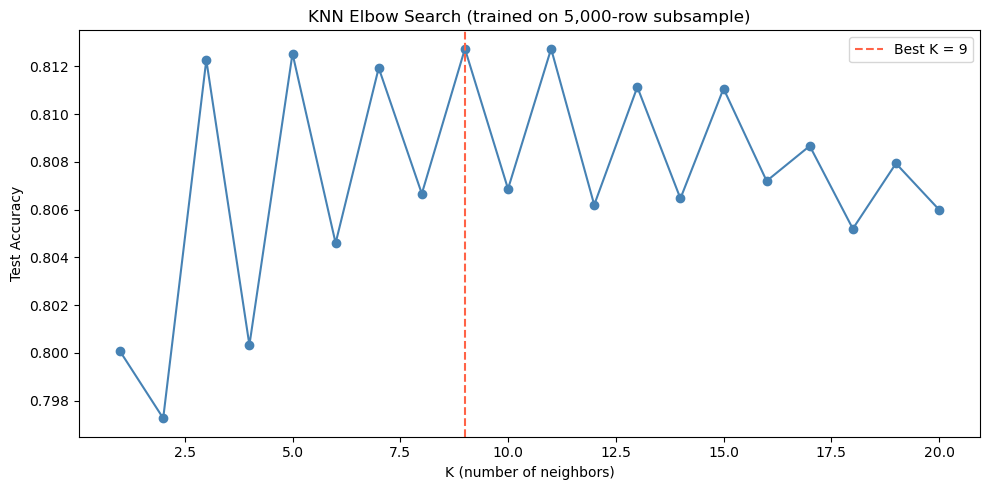

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(k_range), test_accuracies, marker='o', color='steelblue')
ax.axvline(best_k_from_elbow, color='tomato', linestyle='--', label=f'Best K = {best_k_from_elbow}')
ax.set_xlabel('K (number of neighbors)')
ax.set_ylabel('Test Accuracy')
ax.set_title('KNN Elbow Search (trained on 5,000-row subsample)')
ax.legend()
plt.tight_layout()
plt.savefig('knn_elbow.png', dpi=150)
plt.show()

Elbow搜索选出的最优K是9（准确率0.8127），但图上能看到明显的锯齿——奇数K（1,3,5,7,9...）
普遍比相邻的偶数K表现好。这是二分类KNN常见的现象：偶数K容易出现投票打平（比如K=4时
2票对2票），sklearn遇到平局会用固定规则强行打破，导致偶数K系统性地偏弱，不是数据噪声。

因为Elbow只用了5000条子样本、单次划分，结果本身不够稳健，所以这里的K=9只作为后续
网格搜索的参考起点，不直接采用。


#### 9. Hyperparameter Search: n_neighbors, weights, p

Manual grid search with a live `tqdm` progress bar, run on a 20,000-row training
subsample with 3-fold CV (fast: should take only 1-3 minutes total). `GridSearchCV`
itself was avoided here because it gives no visible progress until fully done, which
made it hard to tell if it was stuck.

In [16]:
X_train_for_search, _, y_train_for_search, _ = train_test_split(
    X_train_knn_scaled, y_train_knn,
    train_size=20000,
    random_state=42,
    stratify=y_train_knn
)
X_train_for_search = X_train_for_search.reset_index(drop=True)
y_train_for_search = y_train_for_search.reset_index(drop=True)

param_grid_knn = {
    'n_neighbors': sorted(set([max(1, best_k_from_elbow - 2), best_k_from_elbow,
                                best_k_from_elbow + 2, best_k_from_elbow + 4,
                                best_k_from_elbow + 6])),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
param_combinations = list(itertools.product(
    param_grid_knn['n_neighbors'], param_grid_knn['weights'], param_grid_knn['p']
))
print(f"Testing {len(param_combinations)} parameter combinations x 3-fold = "
      f"{len(param_combinations)*3} total fits")

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
search_results = []

search_start = time.time()
for n_neighbors, weights, p in tqdm(param_combinations, desc="Grid Search Progress"):
    fold_scores = []
    for train_idx, val_idx in skf.split(X_train_for_search, y_train_for_search):
        knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, p=p, algorithm='auto')
        knn.fit(X_train_for_search.iloc[train_idx], y_train_for_search.iloc[train_idx])
        proba = knn.predict_proba(X_train_for_search.iloc[val_idx])[:, 1]
        fold_scores.append(roc_auc_score(y_train_for_search.iloc[val_idx], proba))
    search_results.append({
        'n_neighbors': n_neighbors, 'weights': weights, 'p': p,
        'mean_roc_auc': sum(fold_scores) / len(fold_scores)
    })

print(f"\nGrid search took {time.time()-search_start:.1f} seconds total")

search_results_df = pd.DataFrame(search_results).sort_values('mean_roc_auc', ascending=False)
print(search_results_df)

best_params = search_results_df.iloc[0][['n_neighbors', 'weights', 'p']].to_dict()
best_params['n_neighbors'] = int(best_params['n_neighbors'])
best_params['p'] = int(best_params['p'])
print("\nBest Parameters:", best_params)

Testing 20 parameter combinations x 3-fold = 60 total fits


Grid Search Progress: 100%|██████████| 20/20 [01:17<00:00,  3.90s/it]


Grid search took 77.9 seconds total
    n_neighbors   weights  p  mean_roc_auc
19           15  distance  2      0.867769
17           15   uniform  2      0.866193
15           13  distance  2      0.864032
13           13   uniform  2      0.862443
18           15  distance  1      0.861834
16           15   uniform  1      0.859879
11           11  distance  2      0.858664
14           13  distance  1      0.857838
9            11   uniform  2      0.857034
12           13   uniform  1      0.855797
7             9  distance  2      0.853435
10           11  distance  1      0.852974
5             9   uniform  2      0.851920
8            11   uniform  1      0.851170
6             9  distance  1      0.846858
3             7  distance  2      0.845916
4             9   uniform  1      0.845351
1             7   uniform  2      0.845039
2             7  distance  1      0.837131
0             7   uniform  1      0.835983

Best Parameters: {'n_neighbors': 15, 'weights': 'distance',

网格搜索最终选出的是 **K=15, weights='distance', p=2**（mean ROC-AUC = 0.8678），
比Elbow给出的K=9更大。排名前几位的组合全部集中在K=13和K=15，且都是`weights='distance'`
明显优于`uniform`，说明给更近的邻居更高投票权重确实有帮助。

K=15恰好是本次搜索范围（11-19）里最大的一个，说明真正的最优K可能比15更大，下一步
可以把范围继续往右扩展（比如17-23）验证一下分数是否还在上升，还是已经开始回落。

这里的分数是在20000条子样本+3-fold交叉验证下算出来的，只用来挑参数，不是最终汇报
的结果——真正的表现要看下面用全量训练集重新训练之后的评估。


#### 10. Retrain Final Model on the FULL Training Set

In [17]:
start = time.time()

best_knn_model = KNeighborsClassifier(
    n_neighbors=best_params['n_neighbors'],
    weights=best_params['weights'],
    p=best_params['p'],
    algorithm='auto',
    n_jobs=-1
)
best_knn_model.fit(X_train_knn_scaled, y_train_knn)

print(f"Final model fit on full training set — took {time.time()-start:.1f} seconds")
print(best_knn_model)

Final model fit on full training set — took 2.7 seconds
KNeighborsClassifier(n_jobs=-1, n_neighbors=15, weights='distance')


#### 11. Final Evaluation (same 15,000-row test subsample as the baseline, for a fair comparison)

In [18]:
start = time.time()

y_pred_best_knn       = best_knn_model.predict(X_test_knn_eval)
y_pred_proba_best_knn = best_knn_model.predict_proba(X_test_knn_eval)[:, 1]

accuracy_best_knn  = accuracy_score(y_test_knn_eval, y_pred_best_knn)
precision_best_knn = precision_score(y_test_knn_eval, y_pred_best_knn)
recall_best_knn    = recall_score(y_test_knn_eval, y_pred_best_knn)
f1_best_knn        = f1_score(y_test_knn_eval, y_pred_best_knn)
roc_auc_best_knn   = roc_auc_score(y_test_knn_eval, y_pred_proba_best_knn)

print(f"Final model evaluation — took {time.time()-start:.1f} seconds")
print("Accuracy :", round(accuracy_best_knn, 4))
print("Precision:", round(precision_best_knn, 4))
print("Recall   :", round(recall_best_knn, 4))
print("F1 Score :", round(f1_best_knn, 4))
print("ROC-AUC  :", round(roc_auc_best_knn, 4))

Final model evaluation — took 82.5 seconds
Accuracy : 0.8414
Precision: 0.662
Recall   : 0.6354
F1 Score : 0.6484
ROC-AUC  : 0.8895


In [19]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Baseline (K=5)": [accuracy_knn, precision_knn, recall_knn, f1_knn, roc_auc_knn],
    "Tuned": [accuracy_best_knn, precision_best_knn, recall_best_knn, f1_best_knn, roc_auc_best_knn]
})
comparison["Baseline (K=5)"] = comparison["Baseline (K=5)"].round(4)
comparison["Tuned"] = comparison["Tuned"].round(4)
comparison

,Metric,Baseline (K=5),Tuned
0,Accuracy,0.8301,0.8414
1,Precision,0.6466,0.6620
2,Recall,0.5780,0.6354
3,F1-score,0.6104,0.6484
4,ROC-AUC,0.8617,0.8895


调参后所有指标都有提升，其中**Recall提升最明显**（0.578 → 0.6354，提升了约10%），
ROC-AUC也从0.8617涨到0.8895。这说明调参后的模型能多揪出不少原本被漏判的Unsafe样本，
而且Precision也同步从0.6466涨到0.662，没有出现“为了提Recall牺牲Precision”的情况，
两者是同步改善的，不是简单的trade-off。

Accuracy的提升幅度（0.8301→0.8414）相对较小，这符合预期——因为数据本身77:23不平衡，
Accuracy对这种小幅度的Recall改善不敏感，所以更应该看Recall和ROC-AUC的变化。


#### 12. Confusion Matrix & ROC Curve

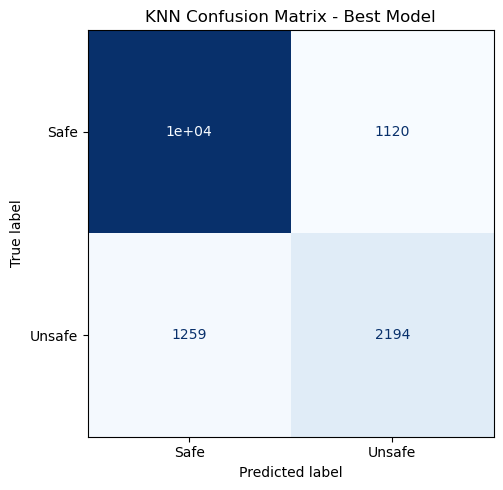

              precision    recall  f1-score   support

        Safe       0.89      0.90      0.90     11547
      Unsafe       0.66      0.64      0.65      3453

    accuracy                           0.84     15000
   macro avg       0.78      0.77      0.77     15000
weighted avg       0.84      0.84      0.84     15000



In [20]:
cm_knn = confusion_matrix(y_test_knn_eval, y_pred_best_knn)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Safe', 'Unsafe'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('KNN Confusion Matrix - Best Model')
plt.tight_layout()
plt.savefig('knn_confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_test_knn_eval, y_pred_best_knn, target_names=['Safe', 'Unsafe']))

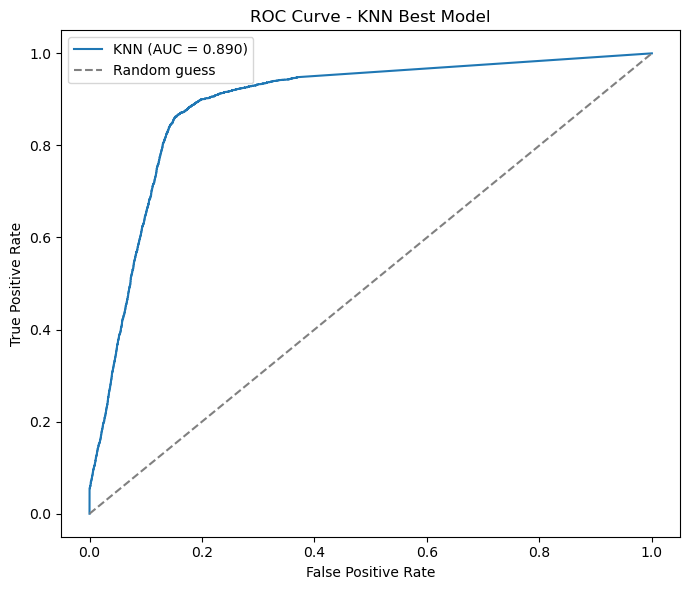

In [21]:
fpr_knn, tpr_knn, _ = roc_curve(y_test_knn_eval, y_pred_proba_best_knn)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_best_knn:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - KNN Best Model')
ax.legend()
plt.tight_layout()
plt.savefig('knn_roc_curve.png', dpi=150)
plt.show()

调参后的KNN模型整体表现：Accuracy 0.8414，Recall（Unsafe类）0.6354，ROC-AUC 0.8895。
从Confusion Matrix看，Unsafe类的Recall只有0.64，意味着仍有约36%的不安全水样被误判
为Safe——这是KNN在这份数据上的主要短板，后续和Random Forest / Gradient Boosting等
ensemble模型对比时，这一点（尤其Recall）会是重要的比较维度。

需要说明的是，以上所有指标都是在15,000条分层抽样的测试子集上算出来的，而不是全部
147,000条测试集。这是出于计算可行性的考虑——KNN的预测开销随训练集和测试集大小同时
增长，全量测试一次大约要5分钟（实测320秒），用分层抽样的子集既能大幅缩短时间，又因为
保留了原始77:23的Safe/Unsafe比例，结果依然具有统计代表性。


#### 13. Final Evaluation on Full Test Set

All previous evaluation steps used a 15,000-row stratified subsample of the test set
for speed (single predict on the full 146,952-row test set takes ~52 minutes). Here
we run the evaluation once on the complete test set to produce the final headline
numbers for the report. Runtime: ~50 minutes — run once and leave it.


In [22]:
import time

start = time.time()

y_pred_full  = best_knn_model.predict(X_test_knn_scaled)
y_proba_full = best_knn_model.predict_proba(X_test_knn_scaled)[:, 1]

elapsed = time.time() - start
print(f"Full test set prediction took {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)")

print("\n--- Final KNN Results (full test set, n=146,952) ---")
print("Accuracy :", round(accuracy_score(y_test_knn,  y_pred_full), 4))
print("Precision:", round(precision_score(y_test_knn, y_pred_full), 4))
print("Recall   :", round(recall_score(y_test_knn,    y_pred_full), 4))
print("F1 Score :", round(f1_score(y_test_knn,        y_pred_full), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test_knn,   y_proba_full), 4))

# Full comparison: subsample vs full test set
comparison_full = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Subsample (n=15k)": [accuracy_best_knn, precision_best_knn,
                           recall_best_knn, f1_best_knn, roc_auc_best_knn],
    "Full test set (n=147k)": [
        accuracy_score(y_test_knn,  y_pred_full),
        precision_score(y_test_knn, y_pred_full),
        recall_score(y_test_knn,    y_pred_full),
        f1_score(y_test_knn,        y_pred_full),
        roc_auc_score(y_test_knn,   y_proba_full)
    ]
})
comparison_full["Subsample (n=15k)"]      = comparison_full["Subsample (n=15k)"].round(4)
comparison_full["Full test set (n=147k)"] = comparison_full["Full test set (n=147k)"].round(4)
comparison_full

Full test set prediction took 1288.2 seconds (21.5 minutes)

--- Final KNN Results (full test set, n=146,952) ---
Accuracy : 0.8403
Precision: 0.6617
Recall   : 0.6266
F1 Score : 0.6437
ROC-AUC  : 0.8893


,Metric,Subsample (n=15k),Full test set (n=147k)
0,Accuracy,0.8414,0.8403
1,Precision,0.6620,0.6617
2,Recall,0.6354,0.6266
3,F1-score,0.6484,0.6437
4,ROC-AUC,0.8895,0.8893
